##SHAP/LIME интерпретируемость BlackBox моделей для ЦБ compliance. XAI для крипто-аудитов

##Введение

###**Актуальность**
 С 30.01.2024в РФ вступил в силу закон ["О цифровых финансовых активах, цифровой валюте и о внесении изменений в отдельные законодательные акты Российской Федерации"](file:///C:/Users/241964/Downloads/250937814-253295278.pdf), который ввел базовые понятия для легализации криптовалютной деятельности. ЦБ внедряет жесткие compliance-требования для операторов ЦФА, операторов ЭПР, банков, криптообменников, брокеров и зарегестрированных майнеров(юр лица и ИП). Основной фокус — ПОД/ФТ (115-ФЗ), аудит смарт-контрактов, контроль за достаточностью капитала (от 3,5 млн руб. оборота), обязательная регистрация в реестре ЦБ и отчетность по подозрительным операциям. Незарегестрированные майнеры - физические лица, составляющие большинство среди участников в обороте криптовалют, а также платежные системы и агрегаторыв свою очередь регулируются косвенно.

  Криптовалютные операции обладают повышенным риском с точки зрения противодействия легализации доходов и финансированию терроризма. По этой причине банки обязаны идентифицировать клиентов а также они вправе запрашивать документы и пояснения об источнике средств и цели операции в соответствии с ст.7 Федерального закона от 07.08.2001 №115-ФЗ, что на практике приводит к усиленному контролю транзакций с участием криптовалют, включая временное приостановление операций до завершения проверок.
  В сложившихся условиях растет необходимость в прозрачности как самих операций и их экономических смыслах для всех участников криптообмена, так и результатов крипто-аудита.

  Многие организации в том числе СБЕРбанк,Т-банк и Росфинмониторинг используют BlackBox модели по типу XGBoost,CatBoost и различные графовые нейронные сети (GNN,GCN). Результаты принятия решений (решения задачи классификации) таких моделей сложно интерпретировать без специальных методов, таких как SHAP/LIME - классических методах интерпретации моделей машинного обучения.





###**Цель**
Цель данной работы-рассмотреть работу библиотек SHAP и LIME в задаче комплаенса(задача множественной классификаци).

В работе используется синтетический датасет поскольку банки не предоставляют данные по реальным транзакциям, нет публичных датасетов по российской специфике а также в целях контроля эксперементальных условий -  доли различных типов субъектов для корректной репрезентации,распределения данных.

###**Задачи**
1. Анализ данных, обратботка данных, EDA, создание новых признаков
2. Моделирование и кросс валидация. Random Forest, SVM, GradientBoosting,XGBoosting
3. Оптимизация - gridsearchcv,SMOTE,RFE
4. Интерпретация- применение методов SHAP и LIME
5. Интерпретация результатов применения методов в контексте задачи

## импорты

In [ ]:
import pandas as pd
from google.colab import drive
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate



##загрузка датасета

In [ ]:
df = pd.read_csv('/content/dataset_for_compliance.csv')

In [ ]:
df.head()

,amount_rub,account_age_days,dist_to_mixer,hops_count,tx_velocity_1h,avg_ticket_30d,smurfing_idx,addr_in_degree,connection_speed,session_duration,...,hour_of_day,is_weekend,kyc_level,client_id,entity_type,ip_region,browser_lang,operation_type,payment_purpose,compliance_result
0,69267.312923,1897,NaN,2,0.567106,63513.577387,0.436495,2,4964.239989,251.207334,...,8,0,1.0,ID_00738,Legal,RU,ru,POS,NaN,0
1,30341.036298,1655,4.671231,10,0.708699,7529.179949,0.022224,7,3438.648964,237.119455,...,22,1,0.0,ID_00678,Legal,DE,zh,SBP,p2p binance,0
2,84288.026503,1872,3.921281,8,0.599235,24930.454002,0.184047,0,4396.833306,209.016810,...,8,1,1.0,ID_00744,Phys,RU,zh,ATM,Salary,2
3,263007.759185,1054,NaN,14,0.013509,36022.539361,0.027119,0,2993.737443,241.800993,...,23,1,NaN,ID_00006,Legal,SG,zh,SBP,NaN,0
4,26785.088512,692,9.096138,13,4.658372,45680.651445,0.364948,2,2359.454499,164.246592,...,11,1,1.0,ID_00840,Phys,DE,zh,SBP,Salary,0


##Анализ и обработка данных

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amount_rub         10000 non-null  float64
 1   account_age_days   10000 non-null  int64  
 2   dist_to_mixer      9200 non-null   float64
 3   hops_count         10000 non-null  int64  
 4   tx_velocity_1h     10000 non-null  float64
 5   avg_ticket_30d     10000 non-null  float64
 6   smurfing_idx       10000 non-null  float64
 7   addr_in_degree     10000 non-null  int64  
 8   connection_speed   10000 non-null  float64
 9   session_duration   10000 non-null  float64
 10  request_cnt        10000 non-null  int64  
 11  hour_of_day        10000 non-null  int64  
 12  is_weekend         10000 non-null  int64  
 13  kyc_level          9500 non-null   float64
 14  client_id          10000 non-null  object 
 15  entity_type        10000 non-null  object 
 16  ip_region          1000

**Признаки**

1. amount_rub - сумма транзакции в рублях
2. account_age_days  - время существования аккаунта
3. hops_count - количество промежуточных узлов в цепочке транзакций
4. tx_velocity_1h - частота транзакций за 1 час
5. avg_ticket_30d - средний чек клиента за последние 30 дней
6. smurfing_idx - вычисляемый индекс смурфинга закрепленный за клиентом
7. addr_in_degree - сколько уникальных отправителей перевели деньги на этот конкретный адрес за последние 24 часа
8. connection_speed  - скорость инетрнет-соединения
9. session_duration - длительность пользовательской сессии в банковском приложении или на веб-интерфейсе крипто-кошелька/обменника
10. request_cnt - количетсво запросов в пользовательской сессии в банковском приложении или на веб-интерфейсе крипто-кошелька/обменника
11. hour_of_day - час дня в который была произведена транзакция
12. is_weekend - индикатор выходного дня
13. kyc_level - урвень идентификации клиента
14. client_id - уникальный ID клиента
15. entity_type - тип клиента(Физлицо, ИП, Юрлицо)
16. ip_region - Регион IP-адреса (RU, KZ, Proxy и др.)
17. browser_lang - Язык интерфейса браузера/системы
18. operation_type - тип операции: СБП, ATM, Card2Card, POS
19. payment_purpose - текстовое назначение платежа

**Целевая переменная**
compliance_result :

0 (Normal): Чистая операция

1 (Suspicious): Подозрение (Alert),  требует ручной проверки аналитиком

2 (High Risk): Высокий риск / Блокировка

In [ ]:
df.describe()

,amount_rub,account_age_days,dist_to_mixer,hops_count,tx_velocity_1h,avg_ticket_30d,smurfing_idx,addr_in_degree,connection_speed,session_duration,request_cnt,hour_of_day,is_weekend,kyc_level,compliance_result
count,1.000000e+04,10000.000000,9200.000000,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,9500.000000,10000.000000
mean,8.421115e+04,1008.441400,5.057249,7.593700,1.495382,4.878057e+04,1.992093e-01,1.985500,5026.644691,239.245839,6.029400,11.66610,0.505500,1.093158,0.147500
std,1.795508e+05,575.318383,2.878086,4.007871,1.497262,6.869011e+04,2.141713e-01,1.398387,1484.498375,90.576490,2.425144,6.96763,0.499995,0.700454,0.522275
min,-1.000000e+00,0.000000,0.000481,1.000000,0.000008,4.436114e+02,6.143807e-11,0.000000,-673.923265,-119.939902,0.000000,0.00000,0.000000,0.000000,0.000000
25%,1.457978e+04,518.000000,2.589883,4.000000,0.432454,1.263312e+04,2.653228e-02,1.000000,4020.730023,178.683028,4.000000,6.00000,0.000000,1.000000,0.000000
50%,3.542631e+04,1017.000000,5.087182,8.000000,1.034782,2.679143e+04,1.175806e-01,2.000000,5033.595570,239.747561,6.000000,12.00000,1.000000,1.000000,0.000000
75%,8.604505e+04,1507.250000,7.499268,11.000000,2.071994,5.689202e+04,3.109585e-01,3.000000,6036.679716,298.203606,8.000000,18.00000,1.000000,2.000000,0.000000
max,5.981064e+06,1999.000000,9.999010,14.000000,13.680265,1.223717e+06,9.855572e-01,12.000000,11303.038850,578.961024,17.000000,23.00000,1.000000,2.000000,2.000000


Заполним пропуски

Полагаем что пропущенные данные в показателе удаленности от известных миксеров означают что они с ними не связаны

In [ ]:
df['dist_to_mixer'] = df['dist_to_mixer'].fillna(999)

Без указания уровня идентификации полагаем самый низкий ее уровень

In [ ]:
df['kyc_level'] = df['kyc_level'].fillna(0)

Без указания цели перевода заполним сооттветствующим идентификатором

In [ ]:
df['payment_purpose'] = df['payment_purpose'].fillna('unknown')

Посмотрим баланс классов в целевой переменной

In [ ]:
classes  = sorted(df['compliance_result'].unique())

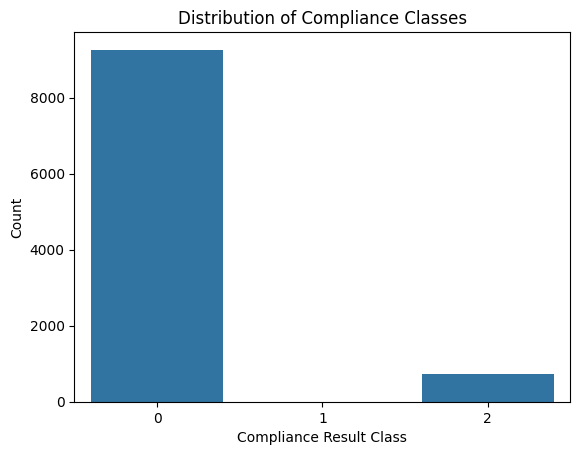

In [ ]:
sns.countplot(x = 'compliance_result',data = df)
plt.title('Distribution of Compliance Classes')
plt.xlabel('Compliance Result Class')
plt.ylabel('Count')
plt.show()

In [ ]:
for i in classes:
  print(f'{len(df[df['compliance_result']== i])} enterances for class {i}')


9260 enterances for class 0
5 enterances for class 1
735 enterances for class 2


Наблюдается сильный дисбаланс классов в целевой переменной что может повлиять на дальнейшее обучение моделей. Учтем это после анализа атрибутов

Расссмотрим качественные признаки датасета

In [ ]:
df.client_id.value_counts()

,count
client_id,
ID_00932,20
ID_00368,19
ID_00519,19
ID_00633,18
ID_00136,18
...,...
ID_00587,3
ID_00349,3
ID_00490,3


In [ ]:
txt_features = df.select_dtypes(include = ['object']).columns.tolist()
for i in txt_features:
  display(df[i].value_counts())

,count
client_id,
ID_00932,20
ID_00368,19
ID_00519,19
ID_00633,18
ID_00136,18
...,...
ID_00587,3
ID_00349,3
ID_00490,3


,count
entity_type,
IE,3355
Phys,3350
Legal,3295


,count
ip_region,
RU,2041
Proxy,2021
KZ,2008
SG,1998
DE,1932


,count
browser_lang,
ar,2570
ru,2491
en,2473
zh,2466


,count
operation_type,
ATM,2542
C2C,2525
POS,2490
SBP,2443


,count
payment_purpose,
unknown,2369
Salary,1307
Loan,1300
crypto buy,1287
transaction,1269
p2p binance,1240
Refund,1228


Как видим все они кроме id клиента можно отнести к категориальным
Применим к каждому из атрибутов One HOt Encoding а id клиентов удалим за ненадобностью

In [ ]:
txt_features.remove('client_id')

In [ ]:
txt_features

['entity_type',
 'ip_region',
 'browser_lang',
 'operation_type',
 'payment_purpose']

In [ ]:
df = pd.get_dummies(df,columns = txt_features)
for col in df.columns:
  if df[col].dtype =='bool':
    df[col] = df[col].astype(int)

In [ ]:
df.columns

Index(['amount_rub', 'account_age_days', 'dist_to_mixer', 'hops_count',
       'tx_velocity_1h', 'avg_ticket_30d', 'smurfing_idx', 'addr_in_degree',
       'connection_speed', 'session_duration', 'request_cnt', 'hour_of_day',
       'is_weekend', 'kyc_level', 'client_id', 'compliance_result',
       'entity_type_IE', 'entity_type_Legal', 'entity_type_Phys',
       'ip_region_DE', 'ip_region_KZ', 'ip_region_Proxy', 'ip_region_RU',
       'ip_region_SG', 'browser_lang_ar', 'browser_lang_en', 'browser_lang_ru',
       'browser_lang_zh', 'operation_type_ATM', 'operation_type_C2C',
       'operation_type_POS', 'operation_type_SBP', 'payment_purpose_Loan',
       'payment_purpose_Refund', 'payment_purpose_Salary',
       'payment_purpose_crypto buy', 'payment_purpose_p2p binance',
       'payment_purpose_transaction', 'payment_purpose_unknown'],
      dtype='object')

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   amount_rub                   10000 non-null  float64
 1   account_age_days             10000 non-null  int64  
 2   dist_to_mixer                10000 non-null  float64
 3   hops_count                   10000 non-null  int64  
 4   tx_velocity_1h               10000 non-null  float64
 5   avg_ticket_30d               10000 non-null  float64
 6   smurfing_idx                 10000 non-null  float64
 7   addr_in_degree               10000 non-null  int64  
 8   connection_speed             10000 non-null  float64
 9   session_duration             10000 non-null  float64
 10  request_cnt                  10000 non-null  int64  
 11  hour_of_day                  10000 non-null  int64  
 12  is_weekend                   10000 non-null  int64  
 13  kyc_level        

In [ ]:
df = df.drop('client_id',axis = 1)

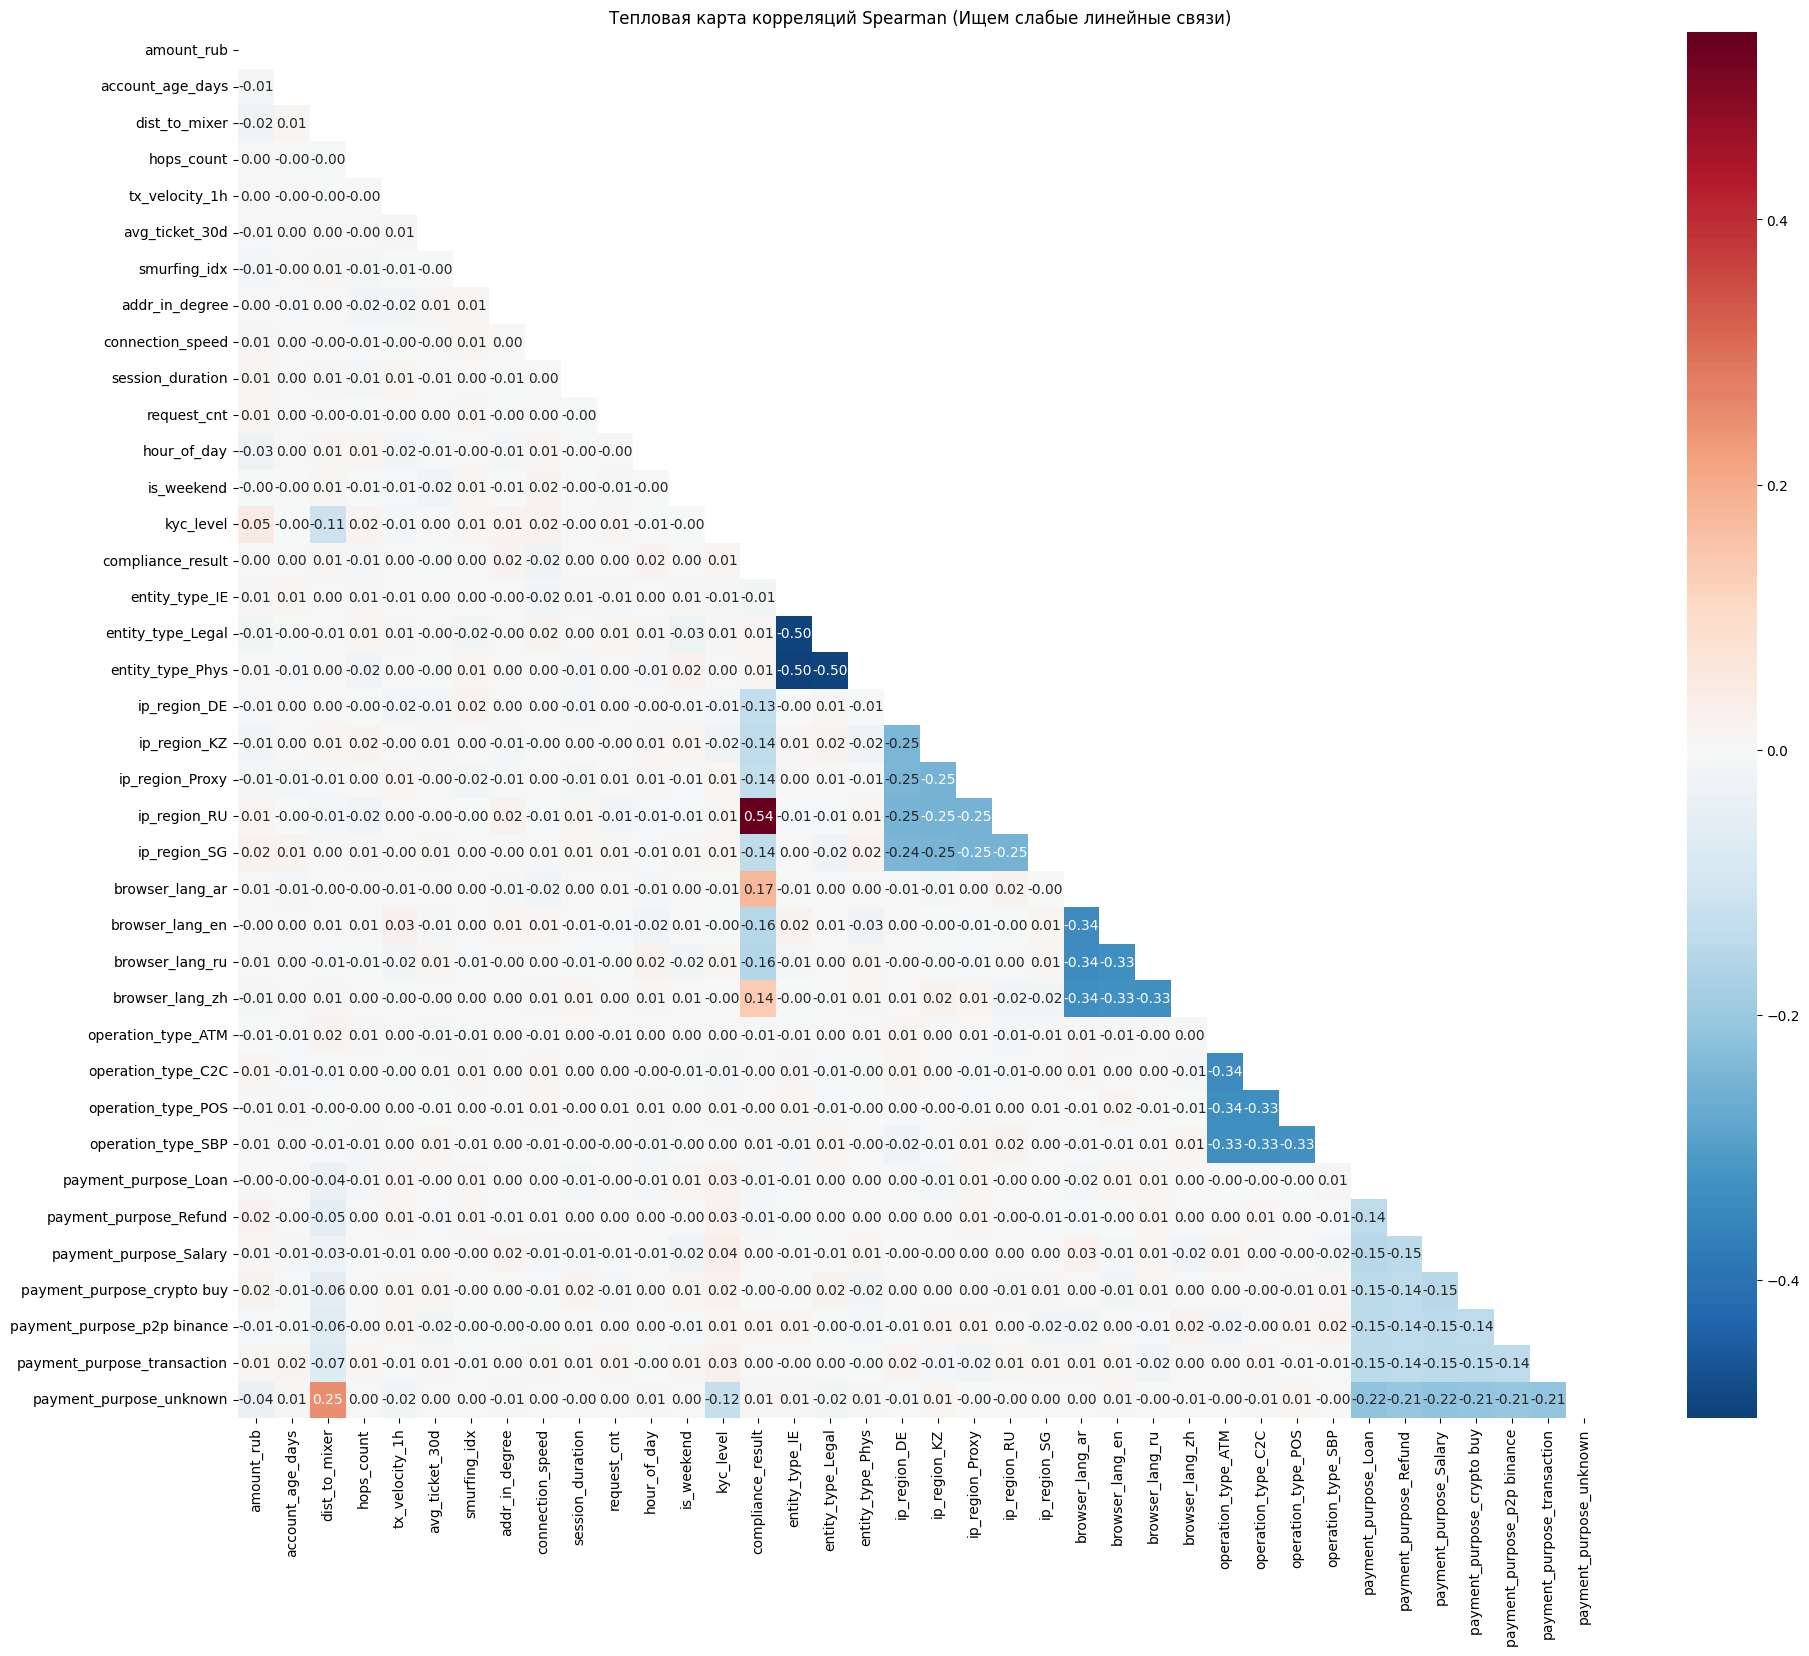

In [ ]:
plt.figure(figsize=(22, 18))
corr = df.corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Тепловая карта корреляций Spearman (Ищем слабые линейные связи)')
plt.show()

Коррелограмма показывает низкие коэффициенты корреляции между таргетом и признаками. Это может означать что здесь имеют место более сложные, нелинейные связи

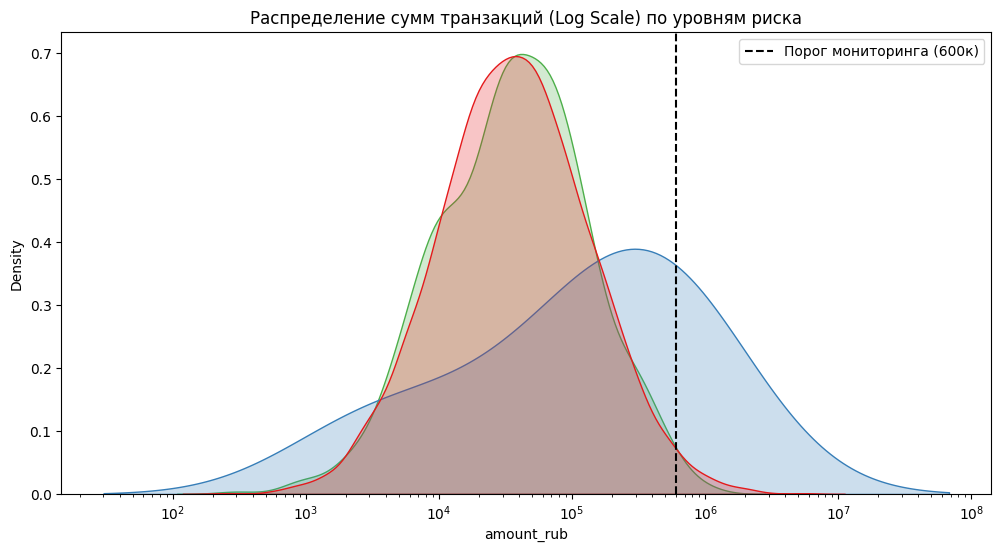

In [ ]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x="amount_rub", hue="compliance_result", fill=True, common_norm=False, palette='Set1', log_scale=True)
plt.axvline(600000, color='black', linestyle='--', label='Порог мониторинга (600к)')
plt.title('Распределение сумм транзакций (Log Scale) по уровням риска')
plt.legend()
plt.show()

Красный график - класс 0, нормальные операции
Зеленые - класс 1
синий - класс 2

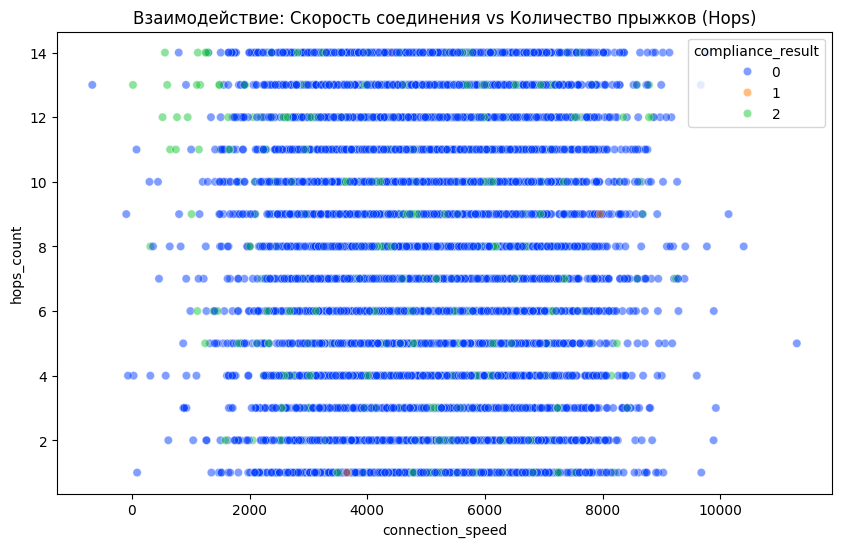

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="connection_speed", y="hops_count", hue="compliance_result",
                    alpha=0.5, palette='bright')
plt.title('Взаимодействие: Скорость соединения vs Количество прыжков (Hops)')
plt.show()


/tmp/ipykernel_1930/3801862398.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='compliance_result', y='session_duration', data=df, palette='Set2')
/tmp/ipykernel_1930/3801862398.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='compliance_result', y='request_cnt', data=df, palette='Set2')


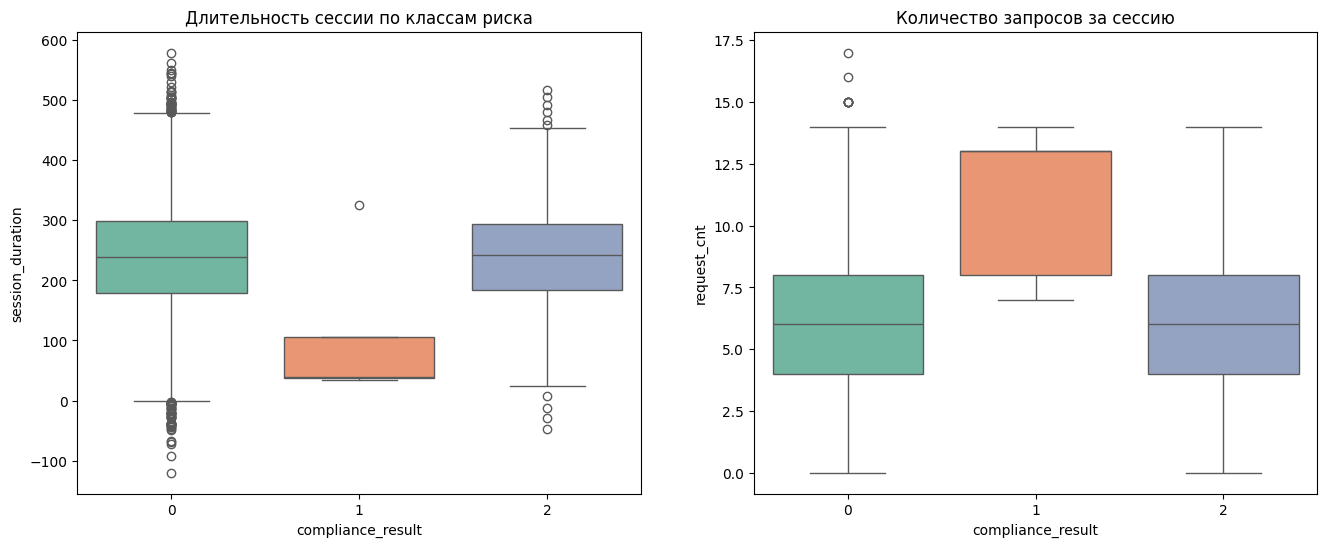

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(ax=axes[0], x='compliance_result', y='session_duration', data=df, palette='Set2')
axes[0].set_title('Длительность сессии по классам риска')
sns.boxplot(ax=axes[1], x='compliance_result', y='request_cnt', data=df, palette='Set2')
axes[1].set_title('Количество запросов за сессию')
plt.show()

Как мы видим подозрительные операции имеют более короткое время сессии и при этом высокое количество запросов.

В то же время инетерсно отметить что заблокированные операции по времени сессии и количествую запросов за сессию почти такие же как и нормальные транзакции.

Обучим модель с добавлением случайного шума и посмотрим какие признаки покажут важность ниже него

In [ ]:

df['random'] = np.random.normal(size=len(df))

X = df.select_dtypes(exclude=['object']).drop(columns=['compliance_result'])
y = df['compliance_result']

rf = RandomForestClassifier().fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
print(importances)

payment_purpose_crypto buy     0.002152
payment_purpose_Refund         0.002540
payment_purpose_transaction    0.002675
payment_purpose_Salary         0.002943
payment_purpose_p2p binance    0.002988
operation_type_POS             0.003049
payment_purpose_Loan           0.003131
operation_type_C2C             0.003148
operation_type_SBP             0.003174
operation_type_ATM             0.003287
payment_purpose_unknown        0.003324
entity_type_Legal              0.003407
entity_type_IE                 0.003972
entity_type_Phys               0.004123
is_weekend                     0.004232
kyc_level                      0.006435
addr_in_degree                 0.011908
request_cnt                    0.015181
hops_count                     0.017176
hour_of_day                    0.019882
ip_region_SG                   0.020836
ip_region_KZ                   0.022481
avg_ticket_30d                 0.023550
ip_region_DE                   0.024097
dist_to_mixer                  0.024329


Выявлены некоторые признаки ( например kyc_level, addr_in_degree,ip_region_DE) которые показали себя менее важными чем случайный шум при формировании результата модели. Несмотря на это удалять эти признаки мы не будем так как они могут быть важны при формировании результата будучи частью ленинейной связи.

##Моделирование и кросс валидация

In [ ]:
X = df.drop(columns=['compliance_result', 'random'])
y = df['compliance_result']

models = {"Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "SVM": SVC(probability=True, kernel='rbf', class_weight='balanced'), # Исправлено на 'rbf'
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, objective='multi:softprob', random_state=42)}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
results = []
for name, model in models.items():
    cv_res = cross_validate(model, X, y, cv=skf, scoring='f1_weighted', n_jobs=-1)
    results.append({"Model": name,
        "F1-Score Mean": cv_res['test_score'].mean(),
        "F1-Score Std": cv_res['test_score'].std()})

results_df = pd.DataFrame(results).sort_values(by="F1-Score Mean", ascending=False)
print(results_df)

               Model  F1-Score Mean  F1-Score Std
2  Gradient Boosting       0.966184      0.003256
3            XGBoost       0.965729      0.002311
0      Random Forest       0.959934      0.003436
1                SVM       0.599432      0.061529


В ходе сравнительного анализа моделей машинного обучения наилучшую эффективность показали алгоритмы градиентного бустинга (Gradient Boosting и XGBoost) с метрикой F1-weighted 0.966 и 0.964 соответственно.

Низкий результат модели SVM (0.60) объясняется высокой нелинейностью связей в признаковом пространстве и чувствительностью алгоритма к дисбалансу классов, даже при использовании весовых коэффициентов.

Надобности в дальнейшей оптимизации не выявлено

##Интерпретация, применение SHAP и LIME

Так как Gradien Boosting, XGBoost и Random Forest показали себя одинаково хорошо, выберем одну из этих моделей для интерпертации

Оба метода SHAP и LIME относятся к категории Explainable AI (XAI) и решают проблему "черного ящика".

Метод LIME (Local Interpretable Model-agnostic Explanations) используется для анализа логики модели на уровне конкретных транзакций.

Алгоритм аппроксимирует поведение сложной нелинейной модели в окрестности конкретного примера с помощью простой дополнительной модели (например, линейной регрессии). Процесс включает генерацию возмущенных данных вокруг выбранного наблюдения и анализ изменения предсказаний исходной модели.

Теоретические основы метода SHAP (SHapley Additive exPlanations)
Метод SHAP основан на концепции значений Шепли, заимствованной из кооперативной теории игр. В рамках данной задачи признаки объекта (транзакции) рассматриваются как игроки, а предсказание модели — как общий выигрыш, который необходимо распределить между ними.
Основные определения:
* $f(x)$ — предсказание модели для конкретного объекта $x$.
* $E[f(x)]$ — базовое (среднее) предсказание модели по всей обучающей выборке.
* $\phi_i$ — значение Шепли для $i$-го признака, отражающее его вклад в отклонение текущего прогноза от среднего.
* $S \subseteq \{1, \dots, M\} \setminus \{i\}$ — подмножество признаков, не включающее исследуемый признак $i$.
Математическая формула значения Шепли:

Вклад каждого признака вычисляется как среднее значение его предельного вклада по всем возможным комбинациям признаков:

$$\phi_i = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|! (M - |S| - 1)!}{M!} [f_S \cup \{i\}(x_{S \cup \{i\}}) - f_S(x_S)]$$
где:

$M$ — общее количество признаков.

$f_S$ — предсказание модели, обученной только на подмножестве признаков $S$.

В итоге сумма вкладов всех признаков в совокупности со средним значением всегда в точности равна итоговому предсказанию модели:

$$f(x) = E[f(x)] + \sum_{i=1}^{M} \phi_i$$

В контексте комплаенс-контроля LIME позволяет сформировать отчет для конкретного инцидента, указав, какие именно параметры послужили причиной  присвоения статуса High Risk/Suspicious.

In [ ]:
rf_model = models["Random Forest"].fit(X, y)
gb_model = models["Gradient Boosting"].fit(X, y)
xgb_model = models["XGBoost"].fit(X, y)

In [ ]:
def plot_shap_for_model(model, model_name, X_data):
    print(f"Расчет SHAP для {model_name}...")

    try:
        # Для XGBoost и Random Forest используем специализированный TreeExplainer
        if model_name in ["XGBoost", "Random Forest"]:
            explainer = shap.TreeExplainer(model)
            sh_values = explainer.shap_values(X_data)
        else:
            # Для Gradient Boosting используем KernelExplainer (через функцию вероятностей)
            background = shap.maskers.Independent(X_data, max_samples=10)
            explainer = shap.Explainer(model.predict_proba, background)
            sh_values = explainer(X_data)

    except Exception as e:
        print(f"Ошибка при расчете {model_name}: {e}")
        return

    if hasattr(sh_values, "values") and len(sh_values.values.shape) == 3:
        plot_data = sh_values.values[:, :, 2]
    elif isinstance(sh_values, list):
        plot_data = sh_values[2]
    # Если это массив (N, M, 3)
    elif len(sh_values.shape) == 3:
        plot_data = sh_values[:, :, 2]
    else:
        plot_data = sh_values

    plt.figure(figsize=(10, 6))
    shap.summary_plot(plot_data, X_data, show=False)
    plt.title(f"SHAP Importance:{model_name} (Class 2: High Risk)")
    plt.show()

Выделяем выборку данных для анализа

In [ ]:
X_sample = X.sample(100, random_state=42)

Расчет SHAP для Random Forest...


/tmp/ipykernel_1930/414161769.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(plot_data, X_data, show=False)


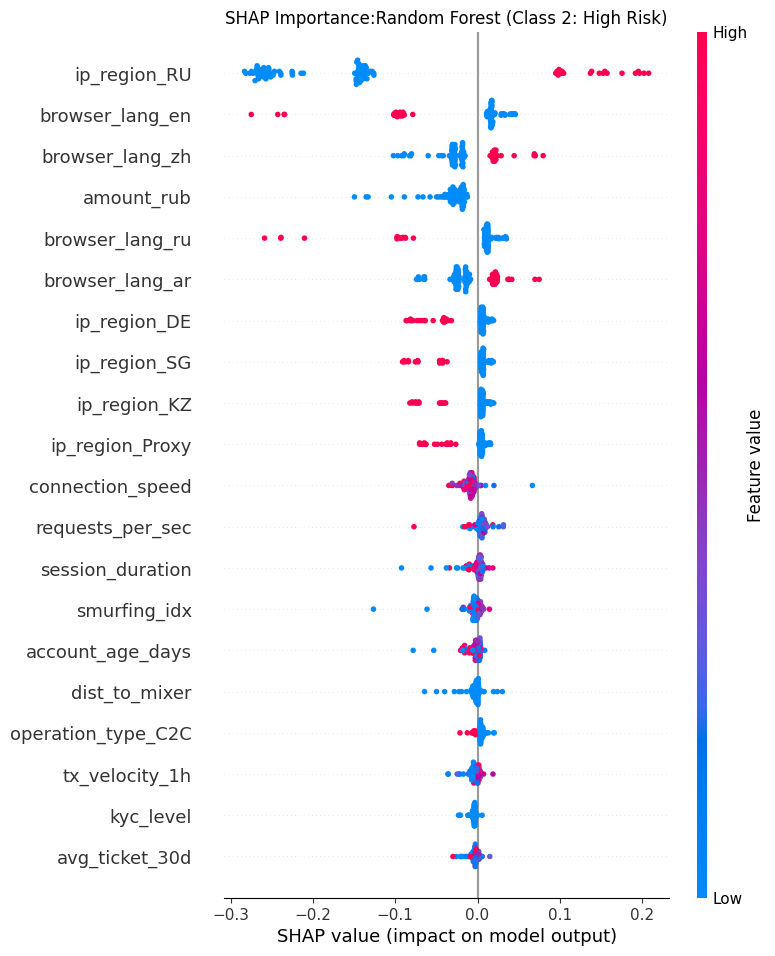

Расчет SHAP для Gradient Boosting...


/tmp/ipykernel_1930/414161769.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(plot_data, X_data, show=False)


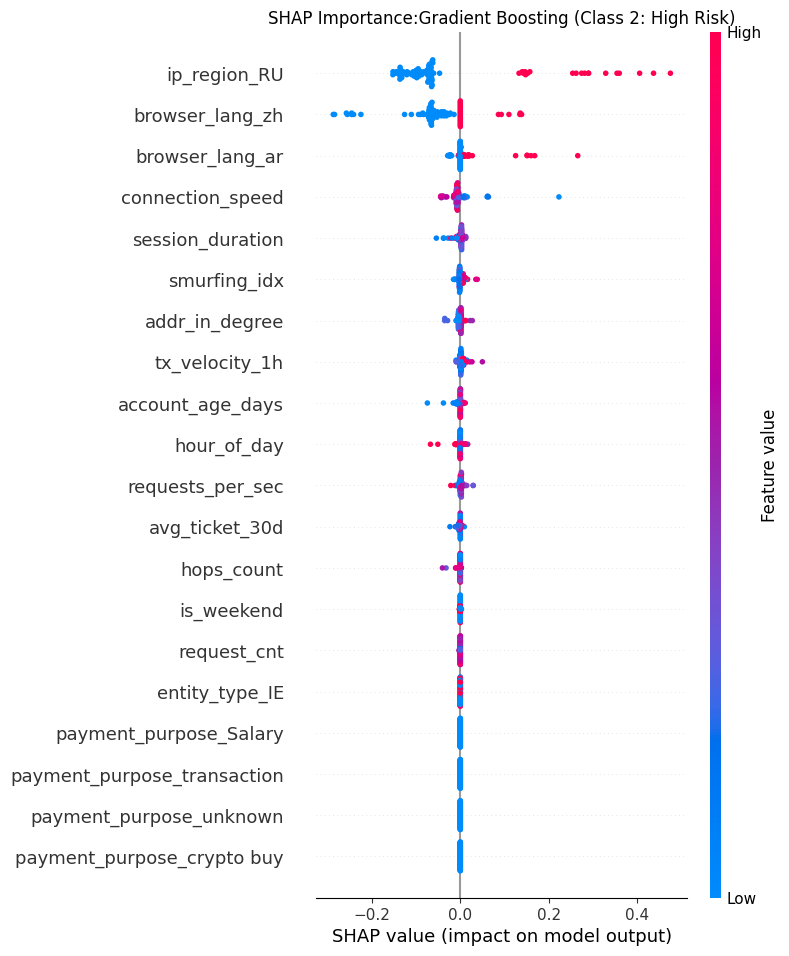

Расчет SHAP для XGBoost...


/tmp/ipykernel_1930/414161769.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(plot_data, X_data, show=False)


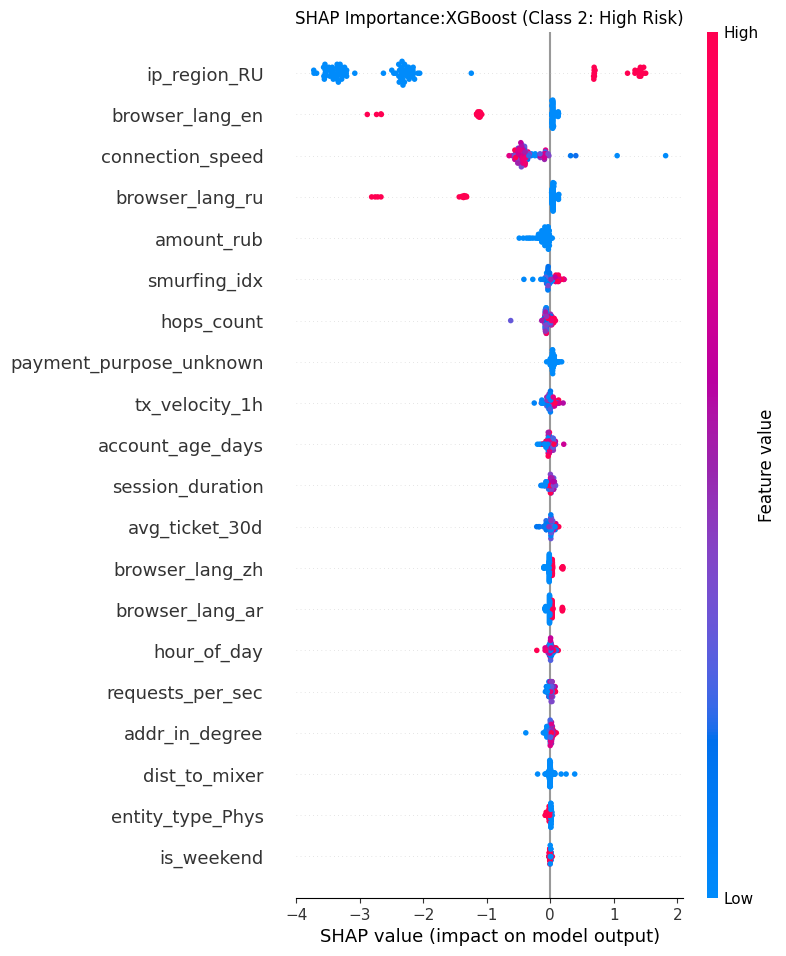

In [ ]:
plot_shap_for_model(rf_model, "Random Forest", X_sample)
plot_shap_for_model(gb_model, "Gradient Boosting", X_sample)
plot_shap_for_model(xgb_model, "XGBoost", X_sample)

LIME — это алгоритм, который может достоверно объяснять предсказания любого классификатора или регрессора, аппроксимируя их локально интерпретируемой моделью. Простыми словами – на промежутке этот алгоритм упрощает нашу сложную, например, полиномиальную модель, до линейной или квадратичной, тем самым упрощая нам её понимание.

Теоретические основы метода LIME (Local Interpretable Model-agnostic Explanations)
Для формализации процесса локальной интерпретации вводится ряд обозначений:
* $x \in \mathbb{R}^d$ — оригинальное представление объекта (исходные данные).
* $x' \in \{0, 1\}^{d'}$ — интерпретируемое бинарное представление объекта.
* $f: \mathbb{R}^d \to \mathbb{R}$ — исходная «сложная» модель, которую мы обучаем (например, градиентный бустинг).
$f(x)$ выражает вероятность принадлежности объекта $x$ к определенному классу.
* $g \in G$ — модель из класса интерпретируемых моделей (например, линейные модели или простые решающие деревья).
* $\Omega(g)$ — функция сложности объяснения модели $g$ (например, количество ненулевых коэффициентов для линейных моделей или глубина дерева).
* $\Pi_x(z)$ — мера близости объекта $z$ к целевому объекту $x$, определяющая «локальность» интерпретации.
* $L(f, g, \Pi_x)$ — мера неверности (loss) модели $g$ по сравнению с $f$ в окрестности $x$.

Математическая постановка задачи

Задачей метода является нахождение такой интерпретируемой модели $\xi$, которая минимизирует неверность при сохранении достаточно низкой сложности:$$\xi = \text{argmin}_{g \in G} L(f, g, \Pi_x) + \Omega(g)$$

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=a7858a749d94e825169053c34904e9a125498e786504dc60161c17280baf6349
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import lime
import lime.lime_tabular


Возьмем первый инстанс сформированной ранее выборки

In [ ]:
instance = X_sample.iloc[0]

Создадим объяснитель LIME

In [ ]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X),
    feature_names=X.columns.tolist(),
    class_names=['Low Risk', 'Warning', 'High Risk'],
    mode='classification',
    discretize_continuous=True,
    random_state=42)

LIME интерпретация для Random Forest

In [ ]:
exp_rf = explainer_lime.explain_instance(
    instance.values,
    rf_model.predict_proba,
    num_features=10,
    top_labels=1 )
exp_rf.show_in_notebook()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


LIME интерпретация для Gradient Boosting

In [ ]:
exp_gb = explainer_lime.explain_instance(
    instance.values,
    gb_model.predict_proba,
    num_features=10,
    top_labels=1)
exp_gb.show_in_notebook()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


LIME интерпретация для XGBoost

In [ ]:
exp_xgb = explainer_lime.explain_instance(
    instance.values,
    xgb_model.predict_proba,
    num_features=10,
    top_labels=1)
exp_xgb.show_in_notebook()

##Интерпретация результатов применения методов

Визуализация SHAP-значений подтвердила, что архитектура Gradient Boosting и XGBoost позволяет выявлять сложные паттерны мошенничества. Основной вклад в классификацию высокого риска вносят географические нестыковки и аномальная интенсивность сетевых запросов.

Что интересно модели демонстрируют нелинейную зависимость:
 аномально высокие суммы в сочетании с другими факторами (например, новым аккаунтом) резко повышают значение Шепли.

Также признак requests_per_sec (интенсивность запросов) показывает четкую положительную корреляцию с уровнем риска на графике XGBoost. Это подтверждает эффективность включения данной метрики для обнаружения например автоматизированных скриптов

На основе графиков LIME для трех моделей (Random Forest, Gradient Boosting и XGBoost), можно сформулировать следующие выводы для интерпретации конкретной транзакции:

1.Единогласность моделей в классификации
Все три алгоритма с абсолютной уверенностью (вероятность 1.00) классифицировали данную транзакцию как Low Risk.

2.Ключевые факторы низкого риска

* ip_region_RU <= 0.00: Отсутствие принадлежности IP-адреса к региону RU в данном конкретном случае снизило вероятность риска сильнее всего

* Языковые настройки браузера: Значения browser_lang_zh <= 0.00 (отсутствие китайского языка) и browser_lang_ar <= 0.00 (отсутствие арабского) также выступили значимыми аргументами в пользу Low Risk

* browser_lang_en > 0.00: Наличие английского языка в настройках браузера при не-российском IP воспринимается всеми моделями как стандартный, безопасный паттерн поведения пользователя

3.Различия в логике моделей

Хотя итоговый прогноз совпал, модели опирались на разные дополнительные признаки:

* Gradient Boosting дополнительно учел признак smurfing_idx > 0.31 и dist_to_mixer > 8.17, но их вклад был минимальным по сравнению с географией

* XGBoost выделил технические параметры сессии, такие как connection_speed и tx_velocity_1h, как дополнительные подтверждающие факторы нормальной активности.

* Random Forest сфокусировался почти исключительно на бинарных флагах регионов и языков (RU, Proxy, SG)

##Список литературы



1.   [LIME](https://arxiv.org/pdf/1602.04938)
2.   [SHAP](https://arxiv.org/pdf/1705.07874)
3.   [SHAP и LIME with examples](https://habr.com/ru/companies/otus/articles/779430/)
4.   [Актуальность](https://www.rbc.ru/crypto/news/69a95d579a79477f7c81fe1e)
5.   [ПОД/ФТ ЦБ](https://cbr.ru/counteraction_m_ter/)
6.   [Текст законопроекта](file:///C:/Users/241964/Downloads/250937814-253295278.pdf)


In [ ]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc
!jupyter nbconvert --to pdf "Тюрина_Алена_ПМ24-1_курсовая.ipynb"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [ ]:
!apt-get install -y texlive-xetex texlive-fonts-recommended texlive-plain-generic


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
texlive-fonts-recommended is already the newest version (2021.20220204-1).
texlive-fonts-recommended set to manually installed.
texlive-plain-generic is already the newest version (2021.20220204-1).
texlive-plain-generic set to manually installed.
texlive-xetex is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
import os
from google.colab import files

# 1. Список всех файлов в текущей директории /content/
# Обычно ваш блокнот доступен здесь, если вы его загрузили или сохранили.
# Если вы просто работаете в браузере, используйте 'Файл' -> 'Скачать .ipynb',
# загрузите его обратно в панель слева и укажите имя ниже.

notebook_name = 'Тюрина_Алена_ПМ24-1_курсовая.ipynb' # Замените на имя вашего файла в панели слева

if os.path.exists(notebook_name):
    !jupyter nbconvert --to pdf "{Тюрина_Алена_ПМ24-1_курсовая}"
    pdf_name = notebook_name.replace('.ipynb', '.pdf')
    files.download(pdf_name)
else:
    print(f"Файл {notebook_name} не найден. Убедитесь, что он загружен в файлы сессии (иконка папки слева).")


Файл Тюрина_Алена_ПМ24-1_курсовая.ipynb не найден. Убедитесь, что он загружен в файлы сессии (иконка папки слева).
